# Shape analysis

In [1]:
import requests
import time
import io
import os

import numpy as np
import pandas as pd

import rocks

from figure_mask import compute_mask, print_statistics

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context("poster")

### Combination DAMIT & SSOFT

In [2]:
# You need SSOFT version 2024.09
# see fink_spins/generate_data.py
data_fink = "../../"
ssoft = pd.read_parquet(os.path.join(data_fink, "data", "ztf", "sso_ZTF.parquet"))

In [3]:
maskFINK_inter = compute_mask(ssoft, thres_spin=1e-3, thres_phase=1e-3, R_min=0.30, model='FINK', kind='inter')
maskFINK_union = compute_mask(ssoft, thres_spin=1e-3, thres_phase=1e-3, R_min=0.30, model='FINK', kind='union')

for model in ['HG', 'HG1G2', 'SHG1G2', 'FINK']:
    print_statistics(ssoft, model)
    print()

mask = maskFINK_union
print(sum(mask))

  All data       : 140559  (100.00%)
  Mask HG (g∩r) : 137746  ( 98.00%)
  Mask HG (gUr) : 137752  ( 98.00%)

  All data       : 140559  (100.00%)
  Mask HG1G2 (g∩r) :  57578  ( 40.96%)
  Mask HG1G2 (gUr) : 101207  ( 72.00%)

  All data       : 140559  (100.00%)
  Mask SHG1G2 (g∩r) :  76798  ( 54.64%)
  Mask SHG1G2 (gUr) : 114519  ( 81.47%)

  All data       : 140559  (100.00%)
  Mask FINK (g∩r) :  57198  ( 40.69%)
  Mask FINK (gUr) :  95470  ( 67.92%)

95470


In [4]:
flavor = "SSHG1G2"

In [5]:
abc = pd.read_csv("../../data/damit_abc.csv")

# Revert b and c if needed 
cond_bc = abc['b'] < abc['c']
print('revert bc', len(abc[cond_bc]))

b = abc.loc[cond_bc,'b']
abc.loc[cond_bc,'b'] = abc.loc[cond_bc,'c']
abc.loc[cond_bc,'c'] = b

# Revert a and b if needed 
cond_ab = abc['a'] < abc['b']
print('revert ab', len(abc[cond_ab]))

a = abc.loc[cond_ab,'a']
abc.loc[cond_ab,'a'] = abc.loc[cond_ab,'b']
abc.loc[cond_ab,'b'] = a


# Revert b and c again if needed 
cond_bc = abc['b'] < abc['c']
print('revert bc', len(abc[cond_bc]))

b = abc.loc[cond_bc,'b']
abc.loc[cond_bc,'b'] = abc.loc[cond_bc,'c']
abc.loc[cond_bc,'c'] = b

# Check
cond_bc = abc['b'] < abc['c']
cond_ab = abc['a'] < abc['b']
print('miss ab, bc', len(abc[cond_ab]), len(abc[cond_bc]))

# abc[cond_bc]
abc

revert bc 0
revert ab 0
revert bc 0
miss ab, bc 0 0


,model_id,asteroid_id,lambda,beta,period,number,name,designation,reference_id,bibcode,a,b,c,R,R2
0,101,101,35.0,-12.0,7.813230,2.0,Pallas,NaN,106,2003icar..164..346t,0.050144,0.047520,0.044016,0.902027,0.902027
1,101,101,35.0,-12.0,7.813230,2.0,Pallas,NaN,139,2011icar..214..652d,0.050144,0.047520,0.044016,0.902027,0.902027
2,106,104,340.0,42.0,7.274471,6.0,Hebe,NaN,106,2003icar..164..346t,0.087539,0.084628,0.074940,0.870793,0.870799
3,106,104,340.0,42.0,7.274471,6.0,Hebe,NaN,139,2011icar..214..652d,0.087539,0.084628,0.074940,0.870793,0.870799
4,110,106,335.0,-5.0,12.866670,8.0,Flora,NaN,106,2003icar..164..346t,0.098508,0.093500,0.086202,0.898516,0.898511
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16312,16275,10853,326.0,-83.0,8.016800,99949.0,Miepgies,NaN,665,2023arxiv230510798d,1.359332,0.883253,0.851780,0.795492,0.795492
16313,16276,10854,34.0,-42.0,143.500000,99973.0,NaN,NaN,665,2023arxiv230510798d,1.510920,0.870606,0.766555,0.693913,0.693914
16314,16277,10854,194.0,-64.0,143.490000,99973.0,NaN,NaN,665,2023arxiv230510798d,1.586496,0.873017,0.728478,0.646806,0.646806
16315,16278,10855,192.0,-52.0,7.071400,99990.0,NaN,NaN,665,2023arxiv230510798d,1.724247,0.872519,0.661044,0.570504,0.570504


## Comparison to literature

In [6]:
data = abc.merge(ssoft[mask], left_on="name", right_on="name", how="left")

# sort by number of observations
data = data.sort_values("n_obs", ascending=False)
# data = data.sort_values(f'{flavor}_rms', ascending=False)

data["DAMIT_a_b"] = data["a"] / data["b"]
data["DAMIT_a_c"] = data["a"] / data["c"]

col_display = ["name", "DAMIT_a_b", "DAMIT_a_c", "SSHG1G2_a_b", "SSHG1G2_a_c"]

# DAMIT HAS DUPLICATES?
data = data.drop_duplicates("name")

data[col_display].head(50)

,name,DAMIT_a_b,DAMIT_a_c,SSHG1G2_a_b,SSHG1G2_a_c
10232,Briggs,1.544837,1.705557,1.031283,2.177942
391,Hektor,2.177053,2.407573,1.105384,1.961828
8267,Diomedes,1.559108,1.746083,1.149288,1.651499
4419,Brendelia,1.327214,1.345692,1.133544,1.681918
6453,Ajax,1.196356,1.411893,1.045777,1.052830
21808,Palamedes,1.244476,1.732739,1.044361,1.793529
1879,Mohler,1.372987,1.490151,1.008311,1.323093
7506,Kashirina,1.181421,1.498235,1.106936,1.064492
666,Lanzia,1.040477,1.860557,1.030679,1.293406
36471,Isaosato,1.423960,1.514885,1.037880,1.676265


### Distributions

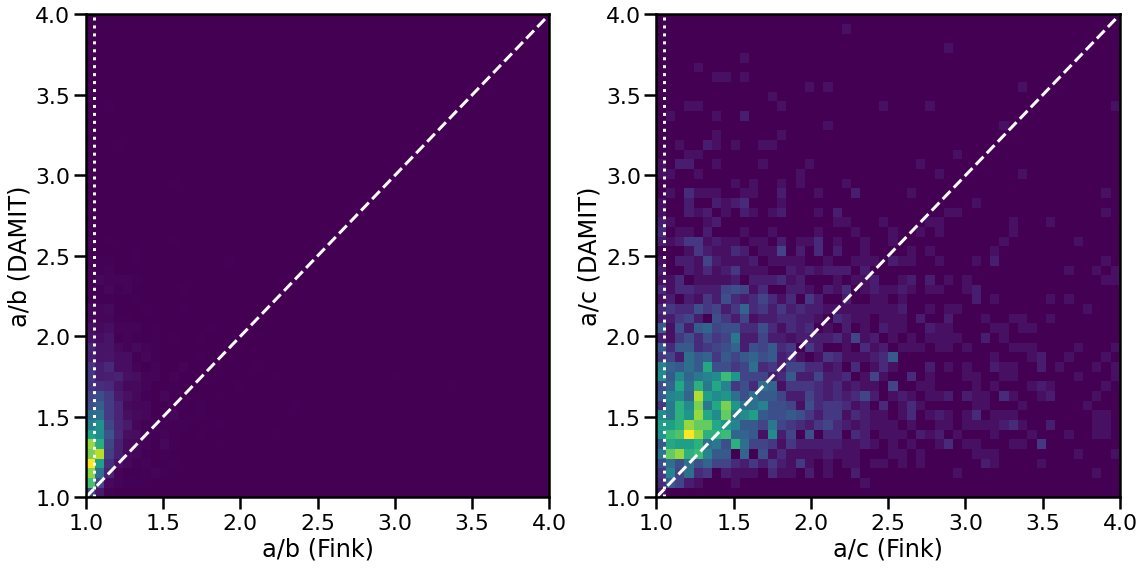

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

r_ab = [1, 4]
r_bc = [1, 4]
r_ac = [1, 4]
b_ab = 50
b_bc = 50
b_ac = 50

fields = ["a_b", "a_c"]
for index in range(2):
    axes[index].hist2d(
        data["SSHG1G2_{}".format(fields[index])], 
        data["DAMIT_{}".format(fields[index])], 
        range=[r_ab, r_bc], 
        bins=[b_ab, b_bc]
    )

    axes[index].axvline(1.05, color='white', ls=":") # p0 in the fit
    

    axes[index].plot(r_ab, r_bc, color="white", ls='--')
    axes[index].set_xlabel("{} (Fink)".format(fields[index]).replace("_", "/"))
    axes[index].set_ylabel("{} (DAMIT)".format(fields[index]).replace("_", "/"))

# axes[1].legend(prop={'size': 15})
plt.tight_layout()

# Why it fails?

One can see that a/b does not move much from `p0` (1.05)... let's take one particularly striking example, Kaneko:

name 	| DAMIT_a_b 	| DAMIT_a_c | SSHG1G2_a_b |	SSHG1G2_a_c|
-|-|-|-|-|
Kaneko | 	2.406216 |	3.452049 |	1.091613 	| 1.767701 |

clearly DAMIT says it is very elongated, while Fink says moderated elongated. Let's inspect the fitted parameters:

In [8]:
cols = ["SSHG1G2_H_g", "SSHG1G2_H_r", "SSHG1G2_G1_r", "SSHG1G2_G2_r", "SSHG1G2_alpha0", "SSHG1G2_delta0", "SSHG1G2_period", "SSHG1G2_phi0", "SSHG1G2_chi2red", "n_obs"]
ssoft[ssoft["name"] == "Kaneko"][cols]

,SSHG1G2_H_g,SSHG1G2_H_r,SSHG1G2_G1_r,SSHG1G2_G2_r,SSHG1G2_alpha0,SSHG1G2_delta0,SSHG1G2_period,SSHG1G2_phi0,SSHG1G2_chi2red,n_obs
55487,11.860723,11.42691,0.281424,0.32765,221.669891,-1.564229,12.769042,-0.570745,21.292704,379.0


The reduced chi2 is not great (21), but looking at Kaneko ssoCard (https://ssp.imcce.fr/forms/ssocard/Kaneko), this is super coherent! So only `a/b` and `a/c` are not discrepant... Let's play with initial values

In [9]:
from fink_utils.sso.spins import estimate_sso_params
import requests
import pandas as pd
import io

name = "Kaneko"

sub = ssoft[ssoft["name"] == name].to_dict(orient="records")[0]

# get data for 4717
r = requests.post(
    'https://fink-portal.org/api/v1/sso',
    json={
        'n_or_d': name,
        'withEphem': True,
        'output-format': 'json'
    }
)

# Format output in a DataFrame
pdf = pd.read_json(io.BytesIO(r.content))

In [10]:
# Initial guess is from SHG1G2 in practice -- but play with values
p0 = [
    sub.get("SHG1G2_H_g", sub["SHG1G2_H_r"]),
    sub.get("SHG1G2_G1_g", sub["SHG1G2_G1_r"]),
    sub.get("SHG1G2_G2_g", sub["SHG1G2_G2_r"]),
    np.deg2rad(sub["SHG1G2_alpha0"]),
    np.deg2rad(sub["SHG1G2_delta0"]),
    sub["SHG1G2_period"] / 24.,
    1.05,
    1.05,
    0.,
]

bounds = (
    [0, 0, 0, 0, -np.pi / 2, 2.2 / 24.0, 1, 1, -np.pi / 2],
    [30, 1, 1, 2 * np.pi, np.pi / 2, 1000, 5, 5, np.pi / 2],
)

# Constrained Fit
# in-place replacement of parameters `outdic`
outdic = estimate_sso_params(
    pdf['i:magpsf_red'].values,
    pdf['i:sigmapsf'].values,
    np.deg2rad(pdf['Phase'].values),
    pdf['i:fid'].values,
    ra=np.deg2rad(pdf['i:ra'].values),
    dec=np.deg2rad(pdf['i:dec'].values),
    jd=pdf["i:jd"].to_numpy(),
    p0=p0,
    bounds=bounds,
    model='SSHG1G2',
    normalise_to_V=False
)

24 * outdic["period"], outdic["a_b"], outdic["a_c"]

(12.769091379494613, 1.0707863603179355, 1.7445968648526318)

Another idea: the ssoCard gives values for t_0, W_0 and W_p -- it would be interesting to use them as prior in our equation and see if we recover the same values for a/b and a/c.

# Fink - DAMIT period comparison

which is I guess only a subset of what is in the BFT (but no surprise, the pattern is the same)

/tmp/ipykernel_528738/1330305479.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(prop={'size': 15})


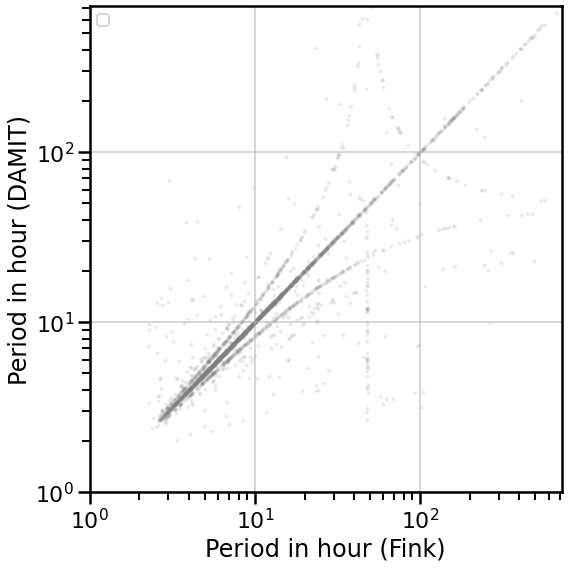

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

maxval = 30*24

ax.scatter(
    data["SSHG1G2_period"],
    data["period"], 
    marker='.', alpha=0.1, s=20, color='grey'
)
# plt.colorbar()
ax.grid(alpha=0.5)
ax.set_xlim(1, maxval)
ax.set_ylim(1, maxval)
ax.set_xlabel("Period in hour (Fink)")
ax.set_ylabel("Period in hour (DAMIT)")
ax.set_xscale("log")
ax.set_yscale("log")

ax.legend(prop={'size': 15})
plt.tight_layout()